In [55]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

In [34]:
df = pd.read_csv('wines_SPA.csv')
df.head()

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


In [35]:
df.tail()

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
7495,Contino,Reserva,2016,4.2,392,Espana,Rioja,19.98,Rioja Red,4.0,3.0
7496,Conreria d'Scala Dei,Les Brugueres,2018,4.2,390,Espana,Priorato,16.76,Priorat Red,4.0,3.0
7497,Mustiguillo,Finca Terrerazo,2017,4.2,390,Espana,El Terrerazo,24.45,Red,4.0,3.0
7498,Matarromera,Gran Reserva,2011,4.2,389,Espana,Ribera del Duero,64.50,Ribera Del Duero Red,5.0,3.0
7499,Sei Solo,Preludio,2016,4.2,388,Espana,Ribera del Duero,31.63,Ribera Del Duero Red,5.0,3.0


In [36]:
df.shape

(7500, 11)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7500 non-null   object 
 1   wine         7500 non-null   object 
 2   year         7498 non-null   object 
 3   rating       7500 non-null   float64
 4   num_reviews  7500 non-null   int64  
 5   country      7500 non-null   object 
 6   region       7500 non-null   object 
 7   price        7500 non-null   float64
 8   type         6955 non-null   object 
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 644.7+ KB


In [38]:
df.columns

Index(['winery', 'wine', 'year', 'rating', 'num_reviews', 'country', 'region',
       'price', 'type', 'body', 'acidity'],
      dtype='object')

In [39]:
df.duplicated().sum()
# wow

5452

In [40]:
df = df.drop_duplicates()

In [41]:
df.shape

(2048, 11)

In [42]:
df.isna().sum()

winery           0
wine             0
year             2
rating           0
num_reviews      0
country          0
region           0
price            0
type           106
body           271
acidity        271
dtype: int64

Let's just drop na values, there is not a lot of them in the dataset

In [43]:
df=df.dropna()

In [44]:
df.shape

(1775, 11)

In [45]:
df.nunique()

winery          425
wine            738
year             71
rating            8
num_reviews     740
country           1
region           66
price          1184
type             21
body              4
acidity           3
dtype: int64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1775 entries, 0 to 2049
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       1775 non-null   object 
 1   wine         1775 non-null   object 
 2   year         1775 non-null   object 
 3   rating       1775 non-null   float64
 4   num_reviews  1775 non-null   int64  
 5   country      1775 non-null   object 
 6   region       1775 non-null   object 
 7   price        1775 non-null   float64
 8   type         1775 non-null   object 
 9   body         1775 non-null   float64
 10  acidity      1775 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 166.4+ KB


It's strange that year is not just an integer.

In [47]:
df['year'].unique()

array(['2013', '2018', '2009', '1999', '1996', '1998', '2010', '1995',
       '2015', '2011', '2016', '1970', '1946', '1962', '2019', '2004',
       'N.V.', '1931', '1979', '2005', '2020', '2014', '1985', '1929',
       '2007', '2012', '2017', '2008', '2006', '2000', '2003', '2002',
       '1991', '1994', '1990', '1989', '1987', '1986', '1981', '2001',
       '1968', '1964', '1982', '1974', '1983', '1955', '1980', '1972',
       '1953', '1958', '1942', '1965', '1992', '1973', '1997', '1967',
       '1975', '1910', '1961', '1954', '1988', '1969', '1951', '1928',
       '1976', '1949', '2021', '1959', '1922', '1978', '1925'],
      dtype=object)

Let's get rid of this N.V and convert year to the integer

In [49]:
df['year'] = df['year'].replace('N.V.', np.NaN)
df = df.dropna()
df['year'] = df['year'].astype(np.int64)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1714 entries, 0 to 2049
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       1714 non-null   object 
 1   wine         1714 non-null   object 
 2   year         1714 non-null   int64  
 3   rating       1714 non-null   float64
 4   num_reviews  1714 non-null   int64  
 5   country      1714 non-null   object 
 6   region       1714 non-null   object 
 7   price        1714 non-null   float64
 8   type         1714 non-null   object 
 9   body         1714 non-null   float64
 10  acidity      1714 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 160.7+ KB


In [51]:
df['country'].unique()

array(['Espana'], dtype=object)

Country column has only one value (which makes sense) so we can delete it

In [52]:
df = df.drop(columns=['country'])
df.head()

,winery,wine,year,rating,num_reviews,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


All string columns are categorical and are easy to change to numbers, so let's do so

In [56]:
print('Categorical columns: ')
for col in df.columns:
    if df[col].dtype == 'object':
        print(str(col))
        label = LabelEncoder()
        label = label.fit(df[col])
        df[col] = label.transform(df[col].astype(str))

Categorical columns: 
winery
wine
region
type


Standarization

In [57]:
df = (df-df.mean())/df.std()
df.head()

,winery,wine,year,rating,num_reviews,region,price,type,body,acidity
0,1.188115,1.165296,0.202515,3.217357,-0.415600,1.268665,2.871153,2.237020,1.114871,0.229031
1,-1.413655,1.398061,0.630837,3.217357,-0.439412,1.515001,0.552423,1.959858,-0.398105,-2.962508
2,1.369251,1.241198,-0.140142,2.556853,1.114560,0.283320,0.591380,0.019728,1.114871,0.229031
3,1.369251,1.241198,-0.996784,2.556853,1.036949,0.283320,1.843494,0.019728,1.114871,0.229031
4,1.369251,1.241198,-1.253777,2.556853,0.687702,0.283320,2.133038,0.019728,1.114871,0.229031


Let's get a correlation table

<Axes: >

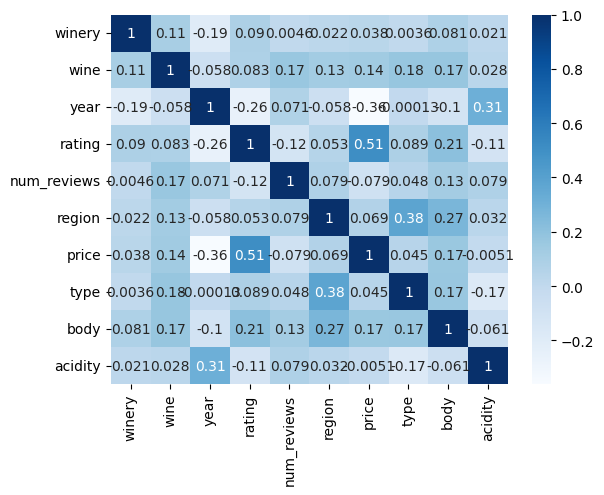

In [58]:
sns.heatmap(df.corr(), annot=True, cmap='Blues')

It seems like for price only matter rating, wine and body but let's try to just build and train the model first

In [60]:
df.columns

Index(['winery', 'wine', 'year', 'rating', 'num_reviews', 'region', 'price',
       'type', 'body', 'acidity'],
      dtype='object')

In [61]:
X = df[['wine', 'year', 'rating', 'num_reviews', 'region', 'price',
       'type', 'body', 'acidity']]

y = df['price']

I'll just use ann regression lectures' code for start

In [62]:
# a nice trick to get all 6 variables for our neural network
# first split 70% for training data, and save the last 30% for temporary variables
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=101)

# then split again the temporary variables by 50% (so if it was 30% originally => now it's
# 15%/15% (because 30% * 50% = 15%))

# so after this, we have 70% for training, 15% testing, and 15% validation
# => 100% in total
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=101)

In [63]:
# 13 variables in this case for training
training_variable_amount = len(X.columns)

# NOTE! This neural network was copied from first example,
# PROBABLY NOT A GOOD SOLUTION FOR THIS DATA

# create the structure of our neural network
model = keras.Sequential(
    [
        layers.Dense(12, activation="relu", input_shape=(training_variable_amount,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1)
    ]
)

# compile the neural network, use adam (most common one) as the optimizer
# and mean square error (mse) for the loss function (most common for regression problems)
model.compile(optimizer='adam', loss='mse')

# show a quick recap of our structure
model.summary()

# start training 
model.fit(x=X_train, y=y_train, epochs=1500, validation_data=(X_val, y_val))



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12)                120       
                                                                 
 dense_1 (Dense)             (None, 8)                 104       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 233 (932.00 Byte)
Trainable params: 233 (932.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/1500

38/38 [==============================] - 1s 5ms/step - loss: 0.9759 - val_loss: 0.9673
Epoch 2/1500
38/38 [==============================] - 0s 2ms/step - loss: 0.8317 - val_loss: 0.7887
Epoch 3/1500
38/38 [==============================] - 0s 2ms/step - loss: 0.661

<Axes: >

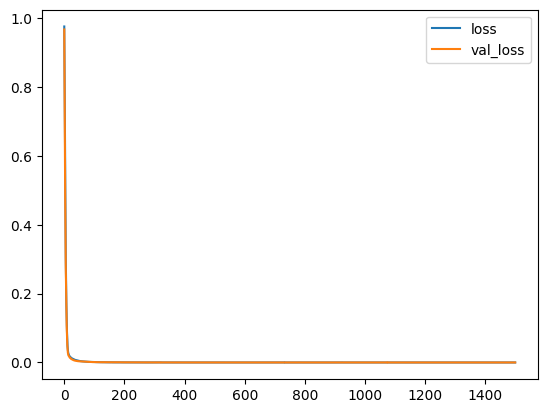

In [64]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [65]:
# these should be as relatively close to each other as possible
# in this case, ~4600 to 4450 is quite close
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
5.680943559127627e-06

Train data evaluation:
3.3360258839820744e-06


In [66]:
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

9/9 [==============================] - 0s 1ms/step


,Test True Y,Model Predictions
0,0.151374,0.150322
1,-0.429507,-0.429826
2,-0.330668,-0.331796
3,-0.424777,-0.425896
4,-0.294773,-0.295426
...,...,...
253,0.019949,0.018606
254,-0.422907,-0.420821
255,0.132227,0.132254
256,-0.296474,-0.296241


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

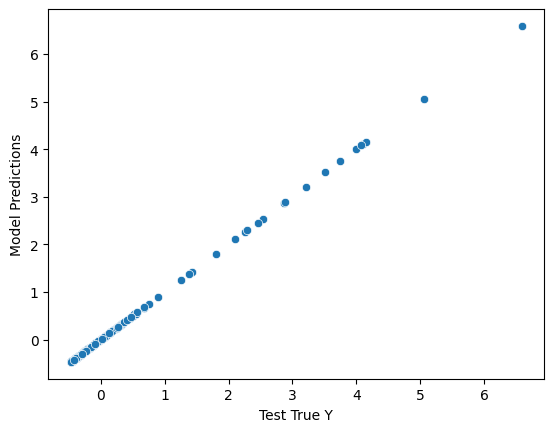

In [67]:
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [68]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
0.0 $

MSE
0.0 $^2

RMSE:
0.0 $

R-squared:
1.0

Explained variance score:
1.0


C:\Users\nikit\AppData\Local\Temp\ipykernel_40756\1775748582.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


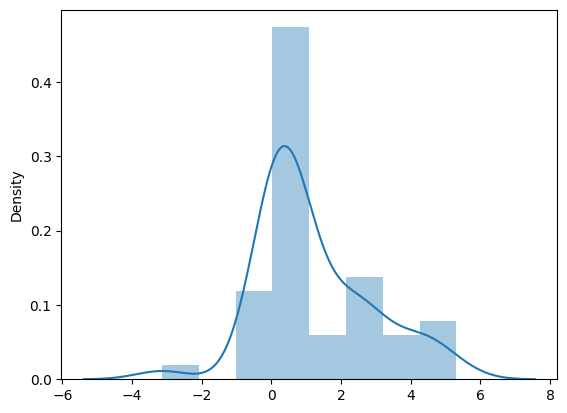

In [69]:
# residual histogram, does our model also follow 
# a normal distribution
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

In [70]:
df.columns

Index(['winery', 'wine', 'year', 'rating', 'num_reviews', 'region', 'price',
       'type', 'body', 'acidity'],
      dtype='object')

In [71]:
df.head(3)

,winery,wine,year,rating,num_reviews,region,price,type,body,acidity
0,1.188115,1.165296,0.202515,3.217357,-0.415600,1.268665,2.871153,2.237020,1.114871,0.229031
1,-1.413655,1.398061,0.630837,3.217357,-0.439412,1.515001,0.552423,1.959858,-0.398105,-2.962508
2,1.369251,1.241198,-0.140142,2.556853,1.114560,0.283320,0.591380,0.019728,1.114871,0.229031


Becasue of stardaization it's hard to come up with custom example so let's skip it

Eror metrics are consfusing.
I guess the model is literally perfect so we're done here.
It'd be good if you could explain if I'm wrong in building or testing process or the data is teh problem or whatever happened.